# Fig Floruit Distribution


In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.duckdb"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## Age at floruit (P1317)

For individuals with **both** a floruit (P1317) and a birthdate (P569), we compute `age_at_floruit = floruit_year - birth_year`. This tells us at what age people tend to be considered "flourishing" — the empirical prior we need to infer floruit when only birth + region are known.

## 0. Date precision coverage by century

Wikidata stores each date with a precision flag. We collapse it into three buckets:

- **year or more precise** — precision 9 (year), 10 (month), 11 (day). The dates we can use as numerical values.
- **decade** — precision 8.
- **century or less precise** — precision 7 (century) and below (millennium, 10k…).

The bar plot below shows the combined count of birth + death dates per century (log scale) over the historically meaningful range, restricted to centuries with at least 10 dates.

In [ ]:
import re
import duckdb
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

DB = DB_PATH

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 12,
    'font.family': 'DejaVu Sans',
})

# --- 1. Load birth + death dates with their precision flags --------------
conn = duckdb.connect(DB, read_only=True)
prec = conn.execute('SELECT birthdate, birthdate_precision, deathdate, deathdate_precision FROM individuals').pl()
conn.close()


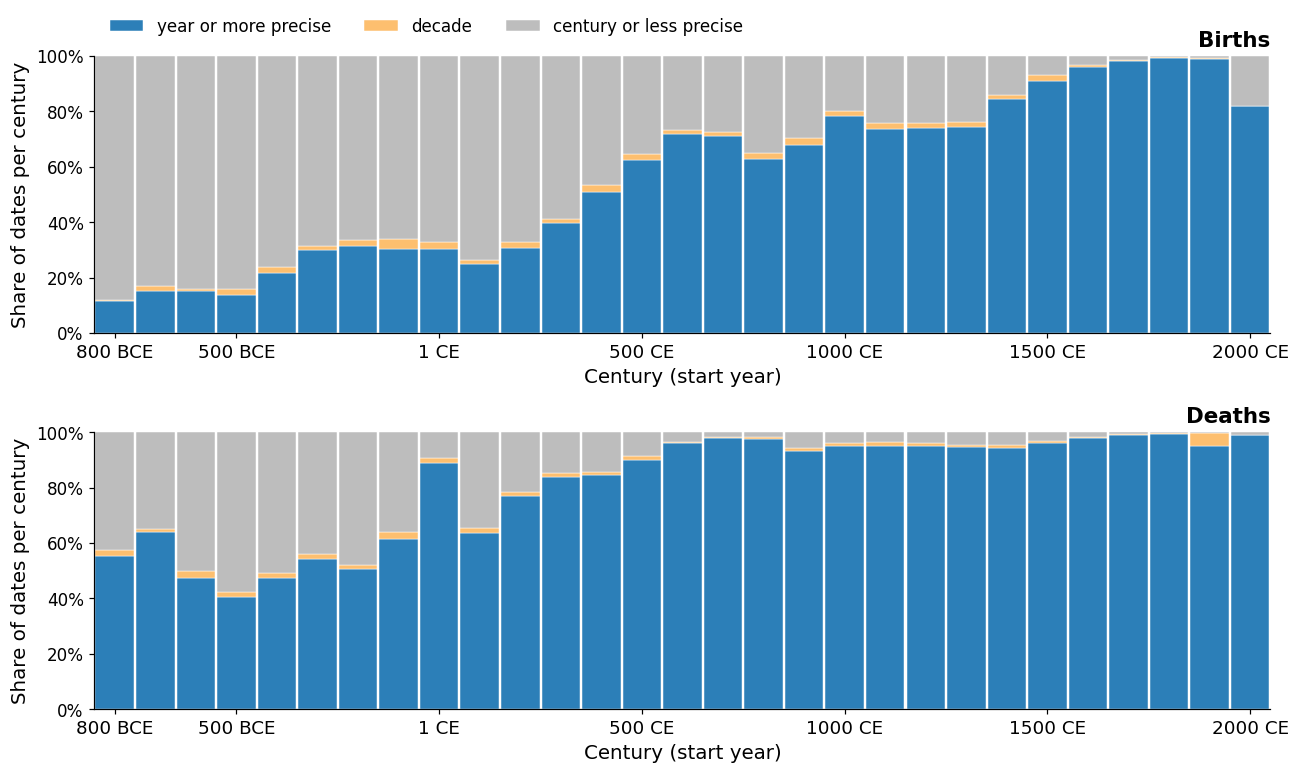

BIRTHS  (range 800 BCE -> 2000 CE)
  total                        7,486,257
  year or more precise        7,325,136  (97.8%)
  decade                         24,562  (0.3%)
  century or less precise       136,559  (1.8%)

DEATHS  (range 800 BCE -> 2000 CE)
  total                        3,530,390
  year or more precise        3,413,177  (96.7%)
  decade                         87,526  (2.5%)
  century or less precise        29,687  (0.8%)



In [3]:


YEAR_RE = re.compile(r'^(-?)(\d+)')

def signed_year(s):
    if not isinstance(s, str): return None
    m = YEAR_RE.match(s.strip())
    if not m: return None
    y = int(m.group(2))
    return -y if m.group(1) == '-' else y

# Wikidata precision codes:
#   11 day, 10 month, 9 year   -> 'year or more precise'
#   8                           -> 'decade'
#   7 century and below        -> 'century or less precise'
def precision_bucket(p):
    if p in (9, 10, 11):           return 'year or more precise'
    if p == 8:                      return 'decade'
    if p is not None and p <= 7:    return 'century or less precise'
    return None

CATS   = ['year or more precise', 'decade', 'century or less precise']
COLORS = {
    'year or more precise':    '#2C7FB8',  # blue   - sharpest
    'decade':                  '#FDBF6F',  # warm orange
    'century or less precise': '#BDBDBD',  # neutral gray - coarsest
}

# --- 2. Per-(century, precision) counts for one date column -------------
def build_table(date_col, prec_col):
    records = []
    for d, p in zip(prec.get_column(date_col).to_list(),
                    prec.get_column(prec_col).to_list()):
        b = precision_bucket(p)
        if b is None: continue
        y = signed_year(d)
        if y is None: continue
        records.append((int(np.floor(y / 100) * 100), b))

    df = pl.DataFrame(records, schema=['century', 'precision'], orient='row')
    wide = (df.group_by(['century', 'precision'])
              .agg(pl.len().alias('n'))
              .pivot(values='n', index='century', on='precision')
              .fill_null(0)
              .sort('century'))
    for col in CATS:
        if col not in wide.columns:
            wide = wide.with_columns(pl.lit(0).alias(col))

    wide = wide.with_columns(
        sum(pl.col(c) for c in CATS).alias('total')
    ).filter(
        (pl.col('total') >= 10)
        & (pl.col('century') >= -800)
        & (pl.col('century') <= 2000)
    )

    c_min, c_max = wide['century'].min(), wide['century'].max()
    all_centuries = list(range(c_min, c_max + 1, 100))
    full = (pl.DataFrame({'century': all_centuries})
              .join(wide, on='century', how='left')
              .fill_null(0)
              .sort('century'))
    centuries = full.get_column('century').to_list()
    totals    = full.get_column('total').to_numpy().astype(float)
    counts    = {c: full.get_column(c).to_numpy().astype(float) for c in CATS}
    # Convert to share (%). Empty centuries get 0/0 -> 0.
    shares = {c: np.divide(counts[c], totals,
                            out=np.zeros_like(counts[c]),
                            where=totals > 0) for c in CATS}
    return centuries, totals, counts, shares

birth_centuries, birth_totals, birth_counts, birth_shares = build_table(
    'birthdate', 'birthdate_precision')
death_centuries, death_totals, death_counts, death_shares = build_table(
    'deathdate', 'deathdate_precision')

# --- 3. Plot helpers -----------------------------------------------------
def year_label(y):
    if y == 0:    return '1 CE'
    if y > 0:     return f'{y} CE'
    return f'{-y} BCE'

def draw_panel(ax, centuries, totals, shares, show_legend):
    x = np.arange(len(centuries))
    has_data = totals > 0

    bottom = np.zeros(len(centuries))
    for c in CATS:
        vals = np.where(has_data, shares[c], 0)
        ax.bar(x, vals, bottom=bottom, width=0.95,
               color=COLORS[c], edgecolor='white', linewidth=0.3,
               label=c, zorder=2)
        bottom = bottom + vals

    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.set_ylabel('Share of dates per century', fontsize=13)

    label_years = {c for c in centuries if c % 500 == 0}
    label_years.update({centuries[0], centuries[-1]})
    xt  = [i for i, c in enumerate(centuries) if c in label_years]
    xtl = [year_label(centuries[i]) for i in xt]
    ax.set_xticks(xt)
    ax.set_xticklabels(xtl, fontsize=12)
    ax.set_xlim(-0.5, len(centuries) - 0.5)
    ax.set_xlabel('Century (start year)', fontsize=13)
    ax.tick_params(axis='y', labelsize=11)

    if show_legend:
        ax.legend(frameon=False, fontsize=11, loc='lower left',
                  bbox_to_anchor=(0.0, 1.02), ncol=3)

# --- 4. Two-panel figure: births (top), deaths (bottom) ------------------
fig, (ax_b, ax_d) = plt.subplots(2, 1, figsize=(12, 7.2), sharex=False)
draw_panel(ax_b, birth_centuries, birth_totals, birth_shares, show_legend=True)
draw_panel(ax_d, death_centuries, death_totals, death_shares, show_legend=False)

ax_b.text(1.0, 1.02, 'Births', transform=ax_b.transAxes,
          fontsize=14, fontweight='bold', ha='right', va='bottom')
ax_d.text(1.0, 1.02, 'Deaths', transform=ax_d.transAxes,
          fontsize=14, fontweight='bold', ha='right', va='bottom')

plt.tight_layout()
plt.show()

# --- 5. Numerical summary -----------------------------------------------
def summarise(name, counts, centuries):
    totals = {c: int(counts[c].sum()) for c in CATS}
    tot = sum(totals.values())
    print(f'{name}  (range {year_label(centuries[0])} -> {year_label(centuries[-1])})')
    print(f'  total                       {tot:>10,}')
    for c in CATS:
        print(f'  {c:<26s} {totals[c]:>10,}  ({totals[c]/tot:.1%})')
    print()

summarise('BIRTHS', birth_counts, birth_centuries)
summarise('DEATHS', death_counts, death_centuries)

## 0b. Combined precision coverage (birth + death merged)

Same precision buckets as above, but pooling birth and death dates into a single per-century share. Useful as a one-glance summary of the dataset's overall date quality through time.

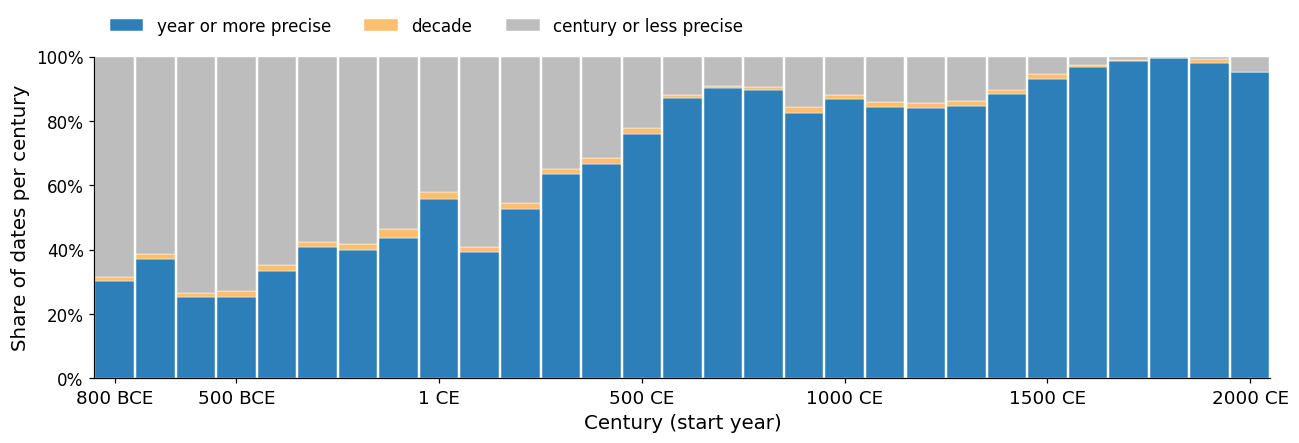

COMBINED  (range 800 BCE -> 2000 CE)
  total                       11,016,647
  year or more precise       10,738,313  (97.5%)
  decade                        112,088  (1.0%)
  century or less precise       166,246  (1.5%)


In [4]:
# Pool birth + death counts on the same century grid, then plot one
# 100%-stacked panel using the helpers defined above.
pooled_centuries = sorted(set(birth_centuries) | set(death_centuries))
pooled_totals = np.zeros(len(pooled_centuries))
pooled_counts = {c: np.zeros(len(pooled_centuries)) for c in CATS}

b_idx = {c: i for i, c in enumerate(birth_centuries)}
d_idx = {c: i for i, c in enumerate(death_centuries)}
for j, c in enumerate(pooled_centuries):
    if c in b_idx:
        i = b_idx[c]
        pooled_totals[j] += birth_totals[i]
        for cat in CATS:
            pooled_counts[cat][j] += birth_counts[cat][i]
    if c in d_idx:
        i = d_idx[c]
        pooled_totals[j] += death_totals[i]
        for cat in CATS:
            pooled_counts[cat][j] += death_counts[cat][i]

pooled_shares = {
    cat: np.divide(pooled_counts[cat], pooled_totals,
                   out=np.zeros_like(pooled_counts[cat]),
                   where=pooled_totals > 0)
    for cat in CATS
}

fig, ax = plt.subplots(figsize=(12, 4.2))
draw_panel(ax, pooled_centuries, pooled_totals, pooled_shares, show_legend=True)
# ax.text(1.0, 1.02, 'Births + Deaths combined', transform=ax.transAxes,
#         fontsize=14, fontweight='bold', ha='right', va='bottom')
plt.tight_layout()
plt.show()

totals = {c: int(pooled_counts[c].sum()) for c in CATS}
tot = sum(totals.values())
print(f'COMBINED  (range {year_label(pooled_centuries[0])} -> {year_label(pooled_centuries[-1])})')
print(f'  total                       {tot:>10,}')
for c in CATS:
    print(f'  {c:<26s} {totals[c]:>10,}  ({totals[c]/tot:.1%})')

In [ ]:
import re
import duckdb
import polars as pl
import pandas as pd  # kept only for tiny in-memory tables built from API responses
import matplotlib.pyplot as plt

DB = DB_PATH

BIN_WIDTH = 500
YEAR_MIN, YEAR_MAX = -3000, 2500
AGE_MIN, AGE_MAX  = 10, 100   # plausibility filter for human flourishing age

def bin_start(year, w=BIN_WIDTH):
    return int(np.floor(year / w) * w)

bin_edges = list(range(YEAR_MIN, YEAR_MAX + 1, BIN_WIDTH))

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '--',
    'font.size': 9,
})


### 1. Load floruit + birth

In [ ]:
conn = duckdb.connect(DB, read_only=True)
Q_AGE = """
SELECT f.wikidata_id,
       f.floruit_period_start,
       f.floruit_precision,
       i.birthdate,
       i.deathdate
FROM individuals_floruit_period f
JOIN individuals i ON i.wikidata_id = f.wikidata_id
WHERE f.floruit_period_start IS NOT NULL
  AND i.birthdate IS NOT NULL
  AND f.floruit_precision >= 9   -- year (9), month (10), day (11) only; drop decade (8), century (7), etc.
"""
raw = conn.execute(Q_AGE).pl()
conn.close()

def signed_year(s):
    if not isinstance(s, str): return None
    m = re.match(r'^(-?)(\d+)', s.strip())
    if not m: return None
    y = int(m.group(2))
    return -y if m.group(1) == '-' else y

raw = (
    raw.with_columns(
        pl.col('birthdate').map_elements(signed_year, return_dtype=pl.Int64).alias('birth_year')
    )
    .drop_nulls(subset=['birth_year'])
    .with_columns(
        pl.col('birth_year').cast(pl.Int64),
        pl.col('floruit_period_start').cast(pl.Int64),
    )
    .with_columns(
        (pl.col('floruit_period_start') - pl.col('birth_year')).alias('age_at_floruit')
    )
)

plausible = raw.filter(
    (pl.col('age_at_floruit') >= AGE_MIN) & (pl.col('age_at_floruit') <= AGE_MAX)
)

n_low  = raw.filter(pl.col('age_at_floruit') < AGE_MIN).height
n_high = raw.filter(pl.col('age_at_floruit') > AGE_MAX).height

print(f'Pairs with floruit (year-precision) & birthdate: {raw.height:,}')
print(f'  age in [{AGE_MIN},{AGE_MAX}]:                 {plausible.height:,}')
print(f'  age < {AGE_MIN}:                              {n_low:,}')
print(f'  age > {AGE_MAX}:                              {n_high:,}')
print()
print('Floruit precision distribution (kept rows):')
print(raw.group_by('floruit_precision').agg(pl.len().alias('count')).sort('floruit_precision'))
print()
print('Summary (plausible subset):')
print(plausible.select('age_at_floruit').describe())

### 2. Overall age distribution

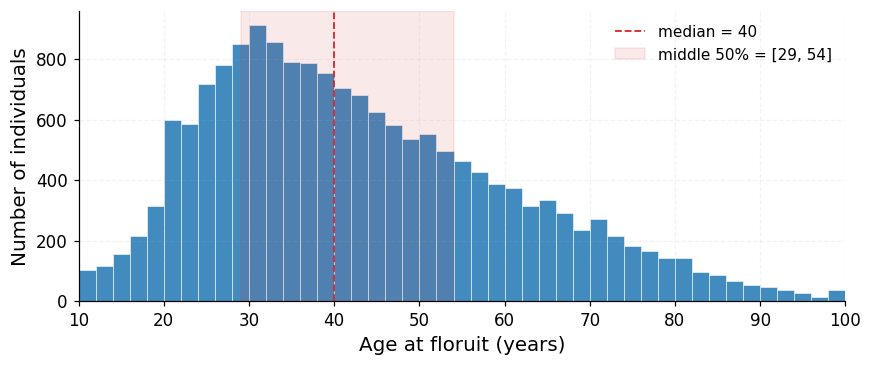

In [7]:
q = plausible['age_at_floruit']
med = float(q.median())
q25 = float(q.quantile(0.25))
q75 = float(q.quantile(0.75))

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(q.to_numpy(), bins=range(AGE_MIN, AGE_MAX + 1, 2),
        color='#2C7FB8', edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(med, color='#d62828', linestyle='--', linewidth=1.2, label=f'median = {med:.0f}')
ax.axvspan(q25, q75, color='#d62828', alpha=0.10, label=f'middle 50% = [{q25:.0f}, {q75:.0f}]')
ax.set_xlabel('Age at floruit (years)')
ax.set_ylabel('Number of individuals')
ax.set_xlim(AGE_MIN, AGE_MAX)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 2.1 Age distribution curves by historical era

One curve per era (KDE of age at floruit), so you can see whether the *typical* flourishing age shifts between Antiquity, the Middle Ages, the Early Modern period, the 19th century and the 20th–21st centuries.

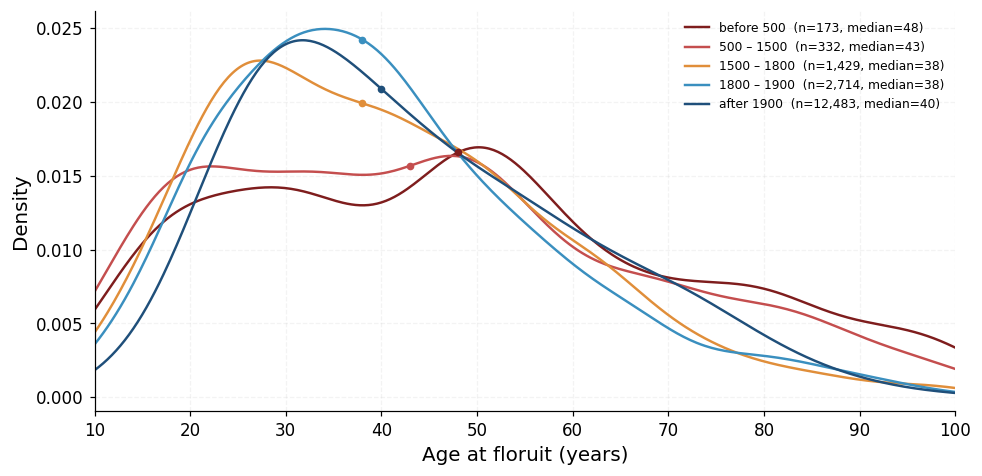

In [8]:
from scipy.stats import gaussian_kde

eras = [
    ('before 500',     None,  500),
    ('500 – 1500',      500, 1500),
    ('1500 – 1800',    1500, 1800),
    ('1800 – 1900',    1800, 1900),
    ('after 1900',     1900, None),
]

palette = ['#7e1d1d', '#c44e4e', '#e08e3a', '#3a8fbf', '#1f4f7a']

x_grid = np.linspace(AGE_MIN, AGE_MAX, 400)

fig, ax = plt.subplots(figsize=(9, 4.4))

for (label, lo, hi), color in zip(eras, palette):
    mask = pl.lit(True)
    if lo is not None:
        mask = mask & (pl.col('floruit_period_start') >= lo)
    if hi is not None:
        mask = mask & (pl.col('floruit_period_start') < hi)
    sub = plausible.filter(mask)['age_at_floruit'].to_numpy()
    if len(sub) < 5:
        continue
    kde = gaussian_kde(sub, bw_method=0.25)
    y = kde(x_grid)
    med = float(np.median(sub))
    ax.plot(x_grid, y, color=color, linewidth=1.6,
            label=f'{label}  (n={len(sub):,}, median={med:.0f})')
    # mark median
    ax.plot([med], [kde(med)[0]], 'o', color=color, markersize=4, zorder=3)

ax.set_xlim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Age at floruit (years)')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

### 2.2 Does age at floruit depend on time?

Two complementary regressions of `age_at_floruit ~ floruit_year`:

- **Unweighted OLS** — every individual contributes equally. Because ~97% of year-precision floruits fall in 1500–2000, this view is dominated by the modern era.
- **Equal-weight-per-time-bin OLS** — each time bin (default 500 years to match the rest of the notebook, plus a 100-year-bin sensitivity check) gets the same total weight regardless of how many individuals it contains. This prevents the modern over-representation from driving the slope and is the proper test of "does floruit-age shift over historical time".

Slopes are reported per century with 95% CIs, plus R² and p-value. A statistically-significant slope with R² near zero would mean: yes, time predicts age, but explains essentially none of the variance — i.e. no *meaningful* relationship.

In [9]:
from scipy import stats

x = plausible['floruit_period_start'].cast(pl.Float64).to_numpy()
y = plausible['age_at_floruit'].cast(pl.Float64).to_numpy()
n = len(x)

# --- Overall distribution (numbers used in the paper paragraph) ---
print('=== OVERALL AGE-AT-FLORUIT DISTRIBUTION ===')
print(f'  n        = {n:,}')
print(f'  mean     = {y.mean():.2f}')
print(f'  median   = {np.median(y):.2f}')
print(f'  q25, q75 = {np.quantile(y, 0.25):.0f}, {np.quantile(y, 0.75):.0f}')
print(f'  std      = {y.std():.2f}')
print()

# --- Weighted-OLS helper: each observation carries weight w_i ---
def weighted_linregress(xv, yv, wv):
    sw  = wv.sum()
    xw  = (wv * xv).sum() / sw
    yw  = (wv * yv).sum() / sw
    dx  = xv - xw
    dy  = yv - yw
    Sxx = (wv * dx * dx).sum()
    Sxy = (wv * dx * dy).sum()
    Syy = (wv * dy * dy).sum()
    beta  = Sxy / Sxx
    alpha = yw - beta * xw
    rss   = (wv * (yv - alpha - beta * xv) ** 2).sum()
    n_eff = (sw ** 2) / (wv * wv).sum()                   # Kish effective n
    df    = max(n_eff - 2, 1.0)
    se    = float(np.sqrt(rss / df / Sxx))
    t     = float(beta / se)
    p     = float(2 * (1 - stats.t.cdf(abs(t), df)))
    r2    = float(1 - rss / Syy)
    return dict(slope=float(beta), intercept=float(alpha), se=se,
                t=t, p=p, r2=r2, n_eff=float(n_eff))

def report(name, res, n_used):
    sl_c   = res['slope'] * 100
    ci_c   = 1.96 * res['se'] * 100
    sig    = 'SIGNIFICANT' if res['p'] < 0.05 else 'not significant'
    print(f'-- {name} --')
    print(f'   n = {n_used:,}    n_eff (Kish) = {res["n_eff"]:.1f}')
    print(f'   slope (per century) = {sl_c:+.3f}  '
          f'[95% CI {sl_c - ci_c:+.3f}, {sl_c + ci_c:+.3f}]')
    print(f'   intercept = {res["intercept"]:.2f}    '
          f'R^2 = {res["r2"]:.4f}    p = {res["p"]:.3g}   ({sig})')
    print()

# --- (a) Unweighted OLS (each individual = 1) ----------------------------
lr = stats.linregress(x, y)
unw = dict(slope=lr.slope, intercept=lr.intercept, se=lr.stderr,
           t=lr.slope / lr.stderr, p=lr.pvalue, r2=lr.rvalue ** 2,
           n_eff=float(n))
print('=== REGRESSION: age_at_floruit ~ floruit_year ===')
report('Unweighted (modern era dominates)', unw, n)

# --- (b) Equal-weight per 500-year bin (matches notebook convention) -----
def equal_weight_regression(xv, yv, bin_width, min_count=1):
    bins = np.floor(xv / bin_width).astype(int) * bin_width
    ub, c = np.unique(bins, return_counts=True)
    keep = set(ub[c >= min_count])
    m = np.isin(bins, list(keep))
    xs, ys, bs = xv[m], yv[m], bins[m]
    cmap = {int(b): int(cc) for b, cc in zip(*np.unique(bs, return_counts=True))}
    wv = np.array([1.0 / cmap[int(b)] for b in bs])  # each bin sums to 1
    return weighted_linregress(xs, ys, wv), int(m.sum()), len(keep)

res_500, n_500, k_500 = equal_weight_regression(x, y, bin_width=500, min_count=1)
report(f'Equal-weight, 500-year bins  ({k_500} bins, all kept)', res_500, n_500)

# --- (c) Sensitivity: 100-year bins, drop bins with <5 individuals -------
res_100, n_100, k_100 = equal_weight_regression(x, y, bin_width=100, min_count=5)
report(f'Equal-weight, 100-year bins (min 5 / bin, {k_100} bins kept)',
       res_100, n_100)

# --- Plain-language verdict for the paper paragraph ---
print('--- VERDICT ---')
print(f'Overall mean age at floruit:  {y.mean():.1f} years '
      f'(median {np.median(y):.0f}; IQR {np.quantile(y, .25):.0f}-{np.quantile(y, .75):.0f}).')
print(f'500-year-bin equal-weight regression:  slope = {res_500["slope"]*100:+.2f} yr/century, '
      f'R^2 = {res_500["r2"]:.4f}, p = {res_500["p"]:.3g}.')
print(f'100-year-bin sensitivity check:        slope = {res_100["slope"]*100:+.2f} yr/century, '
      f'R^2 = {res_100["r2"]:.4f}, p = {res_100["p"]:.3g}.')
if res_500['p'] >= 0.05 and res_100['r2'] < 0.05:
    print('-> No meaningful relationship between floruit age and time: even where the '
          'slope reaches statistical significance at finer resolution, time explains '
          f'< {max(res_500["r2"], res_100["r2"])*100:.1f}% of the variance.')


=== OVERALL AGE-AT-FLORUIT DISTRIBUTION ===
  n        = 17,131
  mean     = 42.67
  median   = 40.00
  q25, q75 = 29, 54
  std      = 17.68

=== REGRESSION: age_at_floruit ~ floruit_year ===
-- Unweighted (modern era dominates) --
   n = 17,131    n_eff (Kish) = 17131.0
   slope (per century) = +0.068  [95% CI -0.036, +0.173]
   intercept = 41.38    R^2 = 0.0001    p = 0.2   (not significant)

-- Equal-weight, 500-year bins  (11 bins, all kept) --
   n = 17,131    n_eff (Kish) = 52.8
   slope (per century) = -0.032  [95% CI -0.458, +0.394]
   intercept = 45.48    R^2 = 0.0004    p = 0.882   (not significant)

-- Equal-weight, 100-year bins (min 5 / bin, 27 bins kept) --
   n = 17,120    n_eff (Kish) = 457.1
   slope (per century) = -0.434  [95% CI -0.694, -0.174]
   intercept = 50.01    R^2 = 0.0230    p = 0.00113   (SIGNIFICANT)

--- VERDICT ---
Overall mean age at floruit:  42.7 years (median 40; IQR 29-54).
500-year-bin equal-weight regression:  slope = -0.03 yr/century, R^2 = 0.00

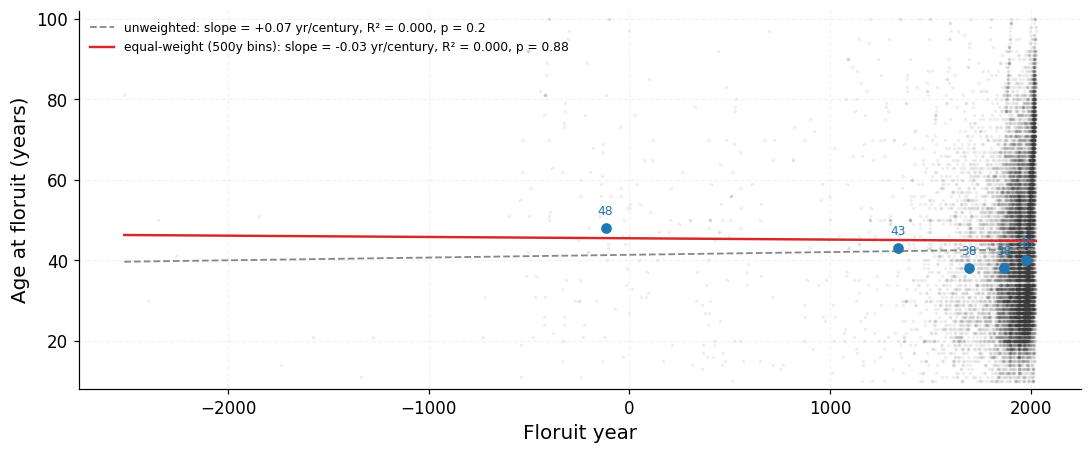

Per-era summary:
shape: (5, 7)
┌─────────────┬───────┬────────┬───────────┬──────┬──────┬───────────┐
│ era         ┆ n     ┆ median ┆ mean      ┆ q25  ┆ q75  ┆ std       │
│ ---         ┆ ---   ┆ ---    ┆ ---       ┆ ---  ┆ ---  ┆ ---       │
│ str         ┆ i64   ┆ f64    ┆ f64       ┆ f64  ┆ f64  ┆ f64       │
╞═════════════╪═══════╪════════╪═══════════╪══════╪══════╪═══════════╡
│ before 500  ┆ 173   ┆ 48.0   ┆ 48.398844 ┆ 30.0 ┆ 63.0 ┆ 23.517618 │
│ 500 - 1500  ┆ 332   ┆ 43.0   ┆ 44.894578 ┆ 26.0 ┆ 59.0 ┆ 22.500575 │
│ 1500 - 1800 ┆ 1429  ┆ 38.0   ┆ 40.287614 ┆ 26.0 ┆ 51.0 ┆ 17.711246 │
│ 1800 - 1900 ┆ 2714  ┆ 38.0   ┆ 40.169492 ┆ 28.0 ┆ 50.0 ┆ 17.059187 │
│ after 1900  ┆ 12483 ┆ 40.0   ┆ 43.348474 ┆ 30.0 ┆ 55.0 ┆ 17.481623 │
└─────────────┴───────┴────────┴───────────┴──────┴──────┴───────────┘


In [10]:
# Per-era summary (median ± IQR + n) so the slope is interpretable
eras = [
    ('before 500',  None,  500),
    ('500 - 1500',   500, 1500),
    ('1500 - 1800', 1500, 1800),
    ('1800 - 1900', 1800, 1900),
    ('after 1900',  1900, None),
]
rows = []
for label, lo, hi in eras:
    m = pl.lit(True)
    if lo is not None: m = m & (pl.col('floruit_period_start') >= lo)
    if hi is not None: m = m & (pl.col('floruit_period_start') < hi)
    sub = plausible.filter(m)['age_at_floruit']
    if sub.len():
        rows.append({
            'era':    label,
            'n':      sub.len(),
            'median': float(sub.median()),
            'mean':   float(sub.mean()),
            'q25':    float(sub.quantile(.25)),
            'q75':    float(sub.quantile(.75)),
            'std':    float(sub.std()),
        })
era_summary = pl.DataFrame(rows)
era_summary

# --- Scatter + both regression lines (unweighted vs equal-weight) + medians ---
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.scatter(x, y, s=2, color='#3a3a3a', alpha=0.05, rasterized=True)

xx = np.linspace(x.min(), x.max(), 100)

# Unweighted line — dominated by the modern era
ax.plot(xx, unw['intercept'] + unw['slope'] * xx,
        color='#888888', linewidth=1.2, linestyle='--',
        label=(f"unweighted: slope = {unw['slope']*100:+.2f} yr/century, "
               f"R² = {unw['r2']:.3f}, p = {unw['p']:.2g}"))

# Equal-weight (500-year bins) — main result
ax.plot(xx, res_500['intercept'] + res_500['slope'] * xx,
        color='#d62828', linewidth=1.6,
        label=(f"equal-weight (500y bins): slope = {res_500['slope']*100:+.2f} yr/century, "
               f"R² = {res_500['r2']:.3f}, p = {res_500['p']:.2g}"))

for label, lo, hi in eras:
    m = pl.lit(True)
    if lo is not None: m = m & (pl.col('floruit_period_start') >= lo)
    if hi is not None: m = m & (pl.col('floruit_period_start') < hi)
    sub_df = plausible.filter(m).select(['age_at_floruit', 'floruit_period_start'])
    if sub_df.height >= 5:
        ymed = float(sub_df['age_at_floruit'].median())
        xmed = float(sub_df['floruit_period_start'].median())
        ax.plot([xmed], [ymed], 'o', color='#1f77b4', markersize=6, zorder=4)
        ax.annotate(f'{ymed:.0f}',
                    xy=(xmed, ymed),
                    xytext=(0, 7), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8, color='#1f77b4')

ax.set_xlabel('Floruit year')
ax.set_ylabel('Age at floruit (years)')
ax.set_ylim(AGE_MIN - 2, AGE_MAX + 2)
ax.legend(frameon=False, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print('Per-era summary:')
print(era_summary)


### 3. Age at floruit through time (500-year bins)

In [11]:
plausible_t = (
    plausible.with_columns(
        ((pl.col('floruit_period_start') // BIN_WIDTH) * BIN_WIDTH).cast(pl.Int64).alias('bin')
    ).filter((pl.col('bin') >= YEAR_MIN) & (pl.col('bin') <= YEAR_MAX))
)

by_bin = (
    plausible_t.group_by('bin')
    .agg([
        pl.len().alias('count'),
        pl.col('age_at_floruit').mean().alias('mean'),
        pl.col('age_at_floruit').median().alias('median'),
        pl.col('age_at_floruit').std().alias('std'),
        pl.col('age_at_floruit').quantile(0.25).alias('q25'),
        pl.col('age_at_floruit').quantile(0.75).alias('q75'),
    ])
    .sort('bin')
)
# Reindex to the canonical bin grid (so missing bins are visible)
by_bin = (
    pl.DataFrame({'bin': bin_edges})
    .join(by_bin, on='bin', how='left')
    .sort('bin')
)
by_bin

bin,count,mean,median,std,q25,q75
i64,u32,f64,f64,f64,f64,f64
-3000,1,81.0,81.0,null,81.0,81.0
-2500,3,40.333333,41.0,10.016653,41.0,50.0
-2000,3,28.666667,21.0,19.655364,21.0,51.0
-1500,2,16.0,16.0,7.071068,11.0,21.0
-1000,13,51.846154,51.0,28.521472,31.0,70.0
…,…,…,…,…,…,…
500,53,47.150943,50.0,21.820418,29.0,65.0
1000,279,44.46595,43.0,22.640244,26.0,58.0
1500,13720,39.863776,37.0,15.766058,28.0,50.0


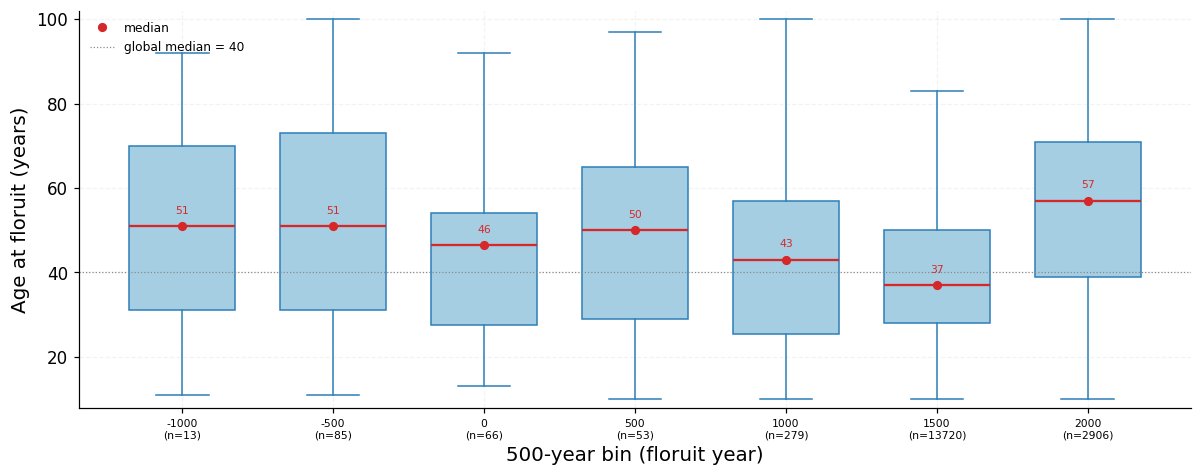

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.4))

data, positions, labels = [], [], []
for b in bin_edges:
    s = plausible_t.filter(pl.col('bin') == b)['age_at_floruit'].to_numpy()
    if len(s) >= 5:
        data.append(s)
        positions.append(b)
        labels.append(f'{b}\n(n={len(s)})')

ax.boxplot(data, positions=positions, widths=BIN_WIDTH * 0.7,
           showfliers=False, patch_artist=True,
           medianprops=dict(color='#d62828', linewidth=1.5),
           boxprops=dict(facecolor='#A6CEE3', edgecolor='#2C7FB8'),
           whiskerprops=dict(color='#2C7FB8'),
           capprops=dict(color='#2C7FB8'))

medians = [float(np.median(d)) for d in data]

# Red dot + value: median per box
ax.plot(positions, medians, 'o', color='#d62828', markersize=5,
        zorder=3, label='median')
for x, m in zip(positions, medians):
    ax.annotate(f'{m:.0f}', xy=(x, m), xytext=(0, 7), textcoords='offset points',
                ha='center', va='bottom', fontsize=7, color='#d62828')

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('Age at floruit (years)')
ax.set_xlabel('500-year bin (floruit year)')
ax.set_ylim(AGE_MIN - 2, AGE_MAX + 2)

global_med = float(plausible_t['age_at_floruit'].median())
ax.axhline(global_med, color='#888', linestyle=':', linewidth=0.8,
           label=f'global median = {global_med:.0f}')

ax.legend(frameon=False, fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## 7. Who adds the floruit property on Wikidata?

To understand the data-generating process behind P1317, we sample N floruit items, walk their revision histories via the MediaWiki API, and pick out revisions whose edit comment mentions `P1317` (Wikidata auto-includes the property ID in edit summaries when a statement is created/changed). Each such revision is attributed to a user, and we classify users as **bots** vs **humans** via the API's user-groups endpoint (a Wikidata bot has the `bot` group flag).

Caveats:
- Sampling — we look at ~1k random items, not all 69k.
- Bulk JSON edits *without* `P1317` in the auto-comment are missed; this slightly underestimates direct API edits but should be a small minority.
- A "P1317 edit" can be create, modify, remove, or rank/reference change — we treat them all as touches.

In [ ]:
import os, json, requests, collections
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

N_SAMPLE = 2000
CACHE = '../data/all_humans/floruit_contributor_revisions.json'

WIKI_API = 'https://www.wikidata.org/w/api.php'
HEADERS = {'User-Agent': 'cultura_database/1.0 (research)'}


def fetch_history(qid):
    """For one item, return:
        creator        — username of the *first* revision (page creator)
        creator_ts     — timestamp of creation
        p1317_edits    — list of revisions whose comment mentions P1317
       Uses rvdir=newer so the first revision arrives first.
    """
    creator, creator_ts = None, None
    p1317 = []
    rvcontinue = None

    for _ in range(10):
        params = {
            'action': 'query',
            'prop': 'revisions',
            'titles': qid,
            'rvlimit': 500,
            'rvdir': 'newer',
            'rvprop': 'user|comment|timestamp|tags',
            'format': 'json',
        }
        if rvcontinue:
            params['rvcontinue'] = rvcontinue
        try:
            data = requests.get(WIKI_API, params=params, headers=HEADERS, timeout=30).json()
        except Exception:
            break

        for page in data.get('query', {}).get('pages', {}).values():
            for rev in page.get('revisions', []):
                if creator is None:
                    creator = rev.get('user')
                    creator_ts = rev.get('timestamp')
                comment = rev.get('comment') or ''
                if 'P1317' in comment:
                    p1317.append({
                        'user': rev.get('user'),
                        'timestamp': rev.get('timestamp'),
                        'comment': comment,
                        'tags': rev.get('tags', []),
                    })

        cont = data.get('continue', {}).get('rvcontinue')
        if not cont:
            break
        rvcontinue = cont

    return {
        'qid': qid,
        'creator': creator,
        'creator_ts': creator_ts,
        'p1317_edits': p1317,
    }


if os.path.exists(CACHE):
    with open(CACHE) as f:
        history = json.load(f)
    print(f'Loaded {len(history):,} cached items from {CACHE}')
else:
    conn = duckdb.connect(DB, read_only=True)
    sample_qids = conn.execute(f'SELECT wikidata_id FROM individuals_floruit_period ORDER BY RANDOM() LIMIT {N_SAMPLE}').pl()['wikidata_id'].to_list()
    conn.close()
    print(f'Sampling {len(sample_qids)} floruit items...')

    history = []
    with ThreadPoolExecutor(max_workers=12) as ex:
        futures = {ex.submit(fetch_history, q): q for q in sample_qids}
        for fut in tqdm(as_completed(futures), total=len(futures), desc='Fetching histories'):
            history.append(fut.result())

    os.makedirs(os.path.dirname(CACHE), exist_ok=True)
    with open(CACHE, 'w') as f:
        json.dump(history, f)
    print(f'Saved {len(history):,} items -> {CACHE}')

n_with_creator = sum(1 for h in history if h['creator'])
n_p1317 = sum(len(h['p1317_edits']) for h in history)
print()
print(f'Items in sample:                 {len(history):,}')
print(f'Items with a creator captured:   {n_with_creator:,}')
print(f'Total P1317-mentioning edits:    {n_p1317:,}')
print(f'Items with at least one such:    {sum(1 for h in history if h["p1317_edits"]):,}'
      f'  ({sum(1 for h in history if h["p1317_edits"]) / len(history):.1%})')

In [14]:
import re

def is_anon_ip(name):
    if not name:
        return False
    if re.match(r'^\d{1,3}(\.\d{1,3}){3}$', name):  # IPv4
        return True
    if ':' in name and re.match(r'^[0-9A-Fa-f:]+$', name):  # IPv6
        return True
    return False


def looks_like_bot(name):
    if not name:
        return False
    n = name.lower()
    return n.endswith('bot') or n.startswith('bot') or 'bot' in n.split('_') or 'bot' in n.split('-')


def get_user_groups(users, batch=50):
    out = {}
    users = [u for u in users if u and not is_anon_ip(u)]
    for i in range(0, len(users), batch):
        b = users[i:i + batch]
        try:
            r = requests.get(WIKI_API, params={
                'action': 'query',
                'list': 'users',
                'ususers': '|'.join(b),
                'usprop': 'groups',
                'format': 'json',
            }, headers=HEADERS, timeout=30).json()
        except Exception:
            continue
        for u in r.get('query', {}).get('users', []):
            out[u['name']] = u.get('groups', [])
    return out


# Build set of all users we ever saw (creators + p1317-edit users)
all_users = {h['creator'] for h in history if h['creator']}
for h in history:
    for r in h['p1317_edits']:
        if r.get('user'):
            all_users.add(r['user'])

named_users = [u for u in all_users if not is_anon_ip(u)]
groups = get_user_groups(named_users)


def classify(user):
    if not user:
        return 'unknown'
    if is_anon_ip(user):
        return 'anonymous IP'
    g = groups.get(user, [])
    if 'bot' in g or looks_like_bot(user):
        return 'bot'
    return 'human'


# --- Item creators ---
creator_counts = collections.Counter(h['creator'] for h in history if h['creator'])
creators_df = (pd.DataFrame({'user': list(creator_counts.keys()),
                             'items_created': list(creator_counts.values())})
                 .assign(type=lambda d: d['user'].map(classify))
                 .sort_values('items_created', ascending=False)
                 .reset_index(drop=True))

print('=== ITEM CREATORS ===  (who first created the floruit Q-item)')
share_creators = creators_df.groupby('type')['items_created'].sum().sort_values(ascending=False)
total_c = share_creators.sum()
for t, n in share_creators.items():
    print(f'  {t:14s} {n:6,}  ({n / total_c:6.1%})')
print()
print('Top 15 item creators:')
print(creators_df.head(15).to_string(index=False))

# --- P1317-statement editors ---
p1317_users = [r['user'] for h in history for r in h['p1317_edits'] if r.get('user')]
p1317_counts = collections.Counter(p1317_users)
p1317_df = (pd.DataFrame({'user': list(p1317_counts.keys()),
                          'p1317_edits': list(p1317_counts.values())})
              .assign(type=lambda d: d['user'].map(classify))
              .sort_values('p1317_edits', ascending=False)
              .reset_index(drop=True))

print()
print('=== DIRECT P1317 EDITORS ===  (revisions whose comment mentions P1317)')
share_p1317 = p1317_df.groupby('type')['p1317_edits'].sum().sort_values(ascending=False)
total_p = share_p1317.sum() if len(p1317_df) else 0
for t, n in share_p1317.items():
    print(f'  {t:14s} {n:6,}  ({n / total_p:6.1%})')
print()
print('Top 15 direct floruit editors:')
print(p1317_df.head(15).to_string(index=False))

=== ITEM CREATORS ===  (who first created the floruit Q-item)
  human              16  ( 80.0%)
  bot                 4  ( 20.0%)

Top 15 item creators:
          user  items_created  type
     Hannolans              6 human
     Infopetal              2 human
    Ambrosia10              1 human
  Karl Oblique              1 human
GZWDer (flood)              1 human
      Finoskov              1 human
     Emijrpbot              1   bot
      BeneBot*              1 human
     Kresspahl              1 human
       Sk!dbot              1   bot
        Dzahsh              1 human
      HuskyBot              1   bot
    Sweet kate              1 human
     MerlIwBot              1   bot

=== DIRECT P1317 EDITORS ===  (revisions whose comment mentions P1317)
  human              10  ( 71.4%)
  bot                 4  ( 28.6%)

Top 15 direct floruit editors:
            user  p1317_edits  type
  BotMultichillT            4   bot
        Finoskov            2 human
       Hannolans           

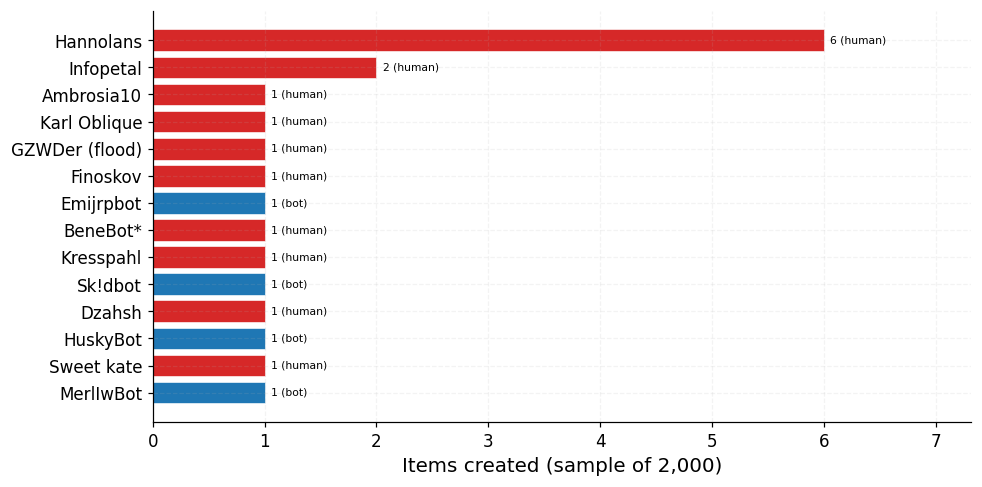

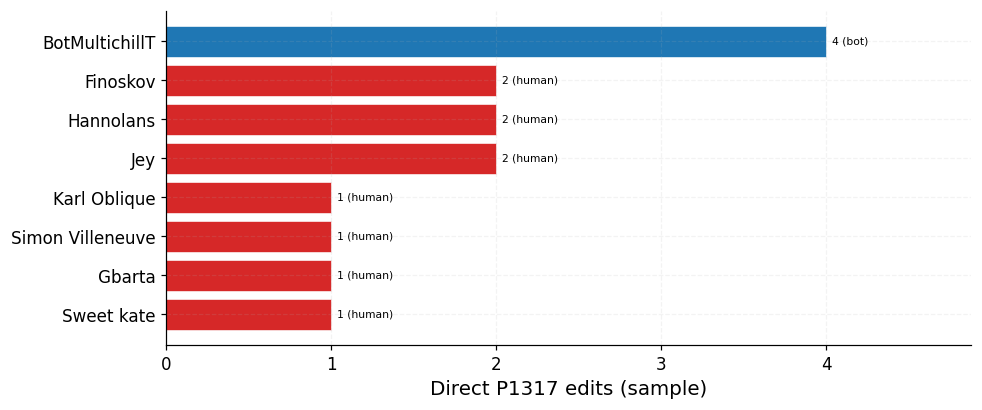

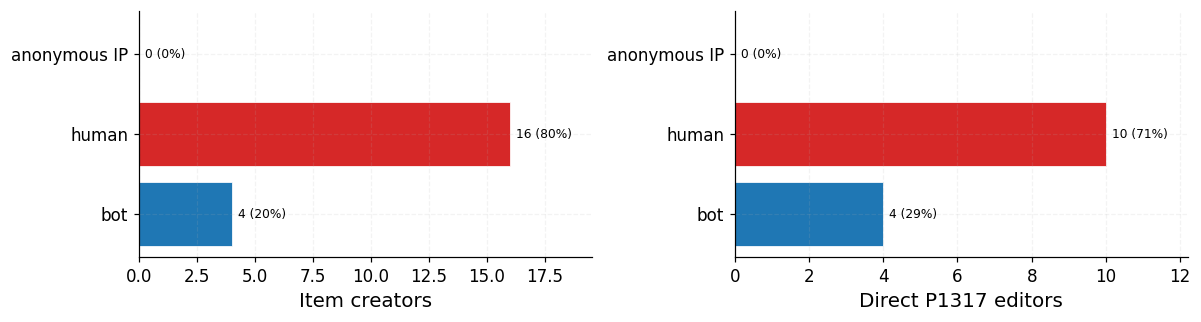

In [15]:
type_color = {'bot': '#1f77b4', 'human': '#d62828',
              'anonymous IP': '#808080', 'unknown': '#cccccc'}

def barh_top(ax, df, value_col, title):
    top = df.head(15).iloc[::-1]
    ax.barh(top['user'], top[value_col],
            color=[type_color.get(t, '#cccccc') for t in top['type']],
            edgecolor='white', linewidth=0.4)
    for y, (n, t) in enumerate(zip(top[value_col], top['type'])):
        ax.annotate(f'{n:,} ({t})', xy=(n, y), xytext=(4, 0),
                    textcoords='offset points', va='center', fontsize=7)
    ax.set_xlabel(title)
    ax.margins(x=0.22)


# Top item creators
fig, ax = plt.subplots(figsize=(9, 4.5))
barh_top(ax, creators_df, 'items_created', 'Items created (sample of {:,})'.format(len(history)))
plt.tight_layout()
plt.show()

# Top direct P1317 editors (if any)
if len(p1317_df):
    fig, ax = plt.subplots(figsize=(9, min(4.5, 0.35 * min(len(p1317_df), 15) + 1)))
    barh_top(ax, p1317_df, 'p1317_edits', 'Direct P1317 edits (sample)')
    plt.tight_layout()
    plt.show()

# Bot vs human breakdown — both views side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
order = ['bot', 'human', 'anonymous IP']
for ax, share, title in [(axes[0], share_creators, 'Item creators'),
                          (axes[1], share_p1317,    'Direct P1317 editors')]:
    vals = [int(share.get(t, 0)) for t in order]
    tot = sum(vals)
    ax.barh(order, vals, color=[type_color[t] for t in order],
            edgecolor='white', linewidth=0.5)
    for y, v in enumerate(vals):
        pct = v / tot if tot else 0
        ax.annotate(f'{v:,} ({pct:.0%})', xy=(v, y), xytext=(4, 0),
                    textcoords='offset points', va='center', fontsize=8)
    ax.set_xlabel(title)
    ax.margins(x=0.22)
plt.tight_layout()
plt.show()

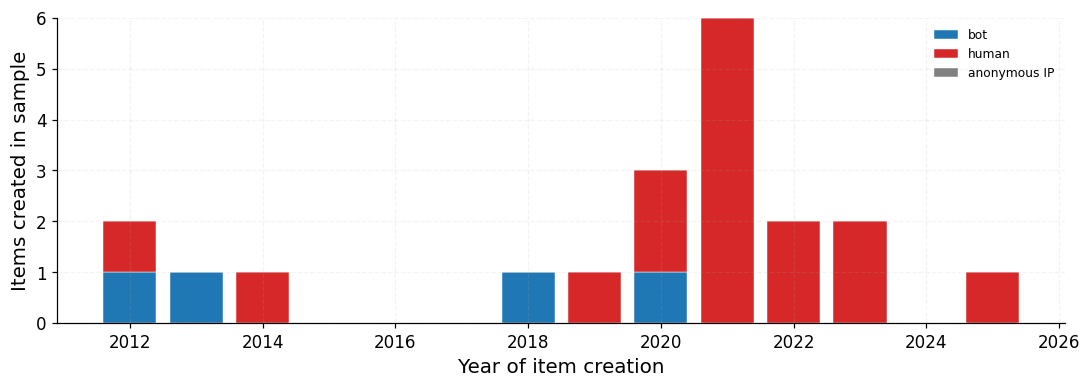

Example direct P1317 edit-comments (first 100 chars):
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 1875
      1  /* wbsetreference-add:2| */ [[Property:P1317]]: 1875
      1  /* wbcreateclaim-create:1| */ [[Property:P1317]]: 1945, #quickstatements; #temporary_batch_164948938
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 16. century
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 17. century
      1  /* wbsetclaim-update:2||1|1 */ [[Property:P1317]]: 17. century
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 1994
      1  /* wbsetreference-add:2| */ [[Property:P1317]]: 1994
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 2015, Add floruit
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 2011, Add floruit


In [16]:
creator_df = pd.DataFrame([{
    'user': h['creator'],
    'ts': h['creator_ts'],
} for h in history if h['creator']])
creator_df['ts']   = pd.to_datetime(creator_df['ts'])
creator_df['year'] = creator_df['ts'].dt.year
creator_df['type'] = creator_df['user'].map(classify)

by_year = (creator_df.groupby(['year', 'type']).size()
                     .unstack(fill_value=0)
                     .reindex(columns=['bot', 'human', 'anonymous IP'], fill_value=0)
                     .sort_index())

fig, ax = plt.subplots(figsize=(10, 3.6))
bottom = np.zeros(len(by_year))
for t in ['bot', 'human', 'anonymous IP']:
    ax.bar(by_year.index, by_year[t].values, bottom=bottom,
           color=type_color[t], edgecolor='white', linewidth=0.3, label=t)
    bottom += by_year[t].values
ax.set_xlabel('Year of item creation')
ax.set_ylabel('Items created in sample')
ax.legend(frameon=False, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# Show example edit-comment patterns where P1317 is explicit
all_p1317 = [r for h in history for r in h['p1317_edits']]
if all_p1317:
    print('Example direct P1317 edit-comments (first 100 chars):')
    samples = (pd.Series([r['comment'][:100] for r in all_p1317])
                 .value_counts().head(10))
    for c, n in samples.items():
        print(f'  {n:5d}  {c}')